# IMU Sensor Fusion: Accel -> Velocity (GRU)

Trains a GRU model that takes a sliding window of accelerometer readings `(ax, ay, az)` and predicts the **next** velocity `(vx, vy, vz)`.

Pipeline:
1. Load `dataset.csv`, keep only `ax, ay, az, vx, vy, vz`
2. EDA: histograms, boxplots (outliers), null/duplicate checks
3. Clean nulls
4. Chronological 70/10/20 train/val/test split (this is a single continuous time series, so splits are contiguous blocks in time rather than randomly shuffled rows, to avoid leaking future information into training)
5. Build sliding-window Dataset/DataLoader (window size = 30, configurable)
6. GRU (2 layers) + ReLU + Linear model in PyTorch
7. Train, evaluate, save weights for later use on the Wokwi/Pico side

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

## 1. Load data and select features

In [2]:
FEATURE_COLS = ['ax', 'ay', 'az']
TARGET_COLS = ['vx', 'vy', 'vz']

df = pd.read_csv('dataset.csv')
df = df[FEATURE_COLS + TARGET_COLS].copy()
df.head()

,ax,ay,az,vx,vy,vz
0,0.737345,0.407073,0.111281,0.017345,0.162485,0.291707
1,0.851926,0.807164,0.119182,0.021504,0.172194,0.289123
2,0.905536,1.000000,0.135950,0.035067,0.212551,0.277894
3,0.707432,0.437925,0.146009,0.057921,0.256612,0.262269
4,0.598767,0.364326,0.153077,0.092895,0.276940,0.248091


## 2. Exploratory data analysis

In [3]:
print('Shape:', df.shape)
print('\nNull values per column:')
print(df.isnull().sum())
print('\nDuplicated rows:', df.duplicated().sum())
df.describe()

Shape: (1225, 6)

Null values per column:
ax    0
ay    0
az    0
vx    0
vy    0
vz    0
dtype: int64

Duplicated rows: 0


,ax,ay,az,vx,vy,vz
count,1225.000000,1225.000000,1225.000000,1225.000000,1225.000000,1225.000000
mean,0.538340,0.465011,0.332757,0.404103,0.564976,0.585774
std,0.133335,0.185434,0.076405,0.196852,0.194320,0.225657
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.447144,0.328822,0.307389,0.270272,0.435893,0.576183
50%,0.542093,0.464627,0.326470,0.396915,0.555654,0.583844
75%,0.628078,0.599057,0.347992,0.541459,0.681296,0.593352
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


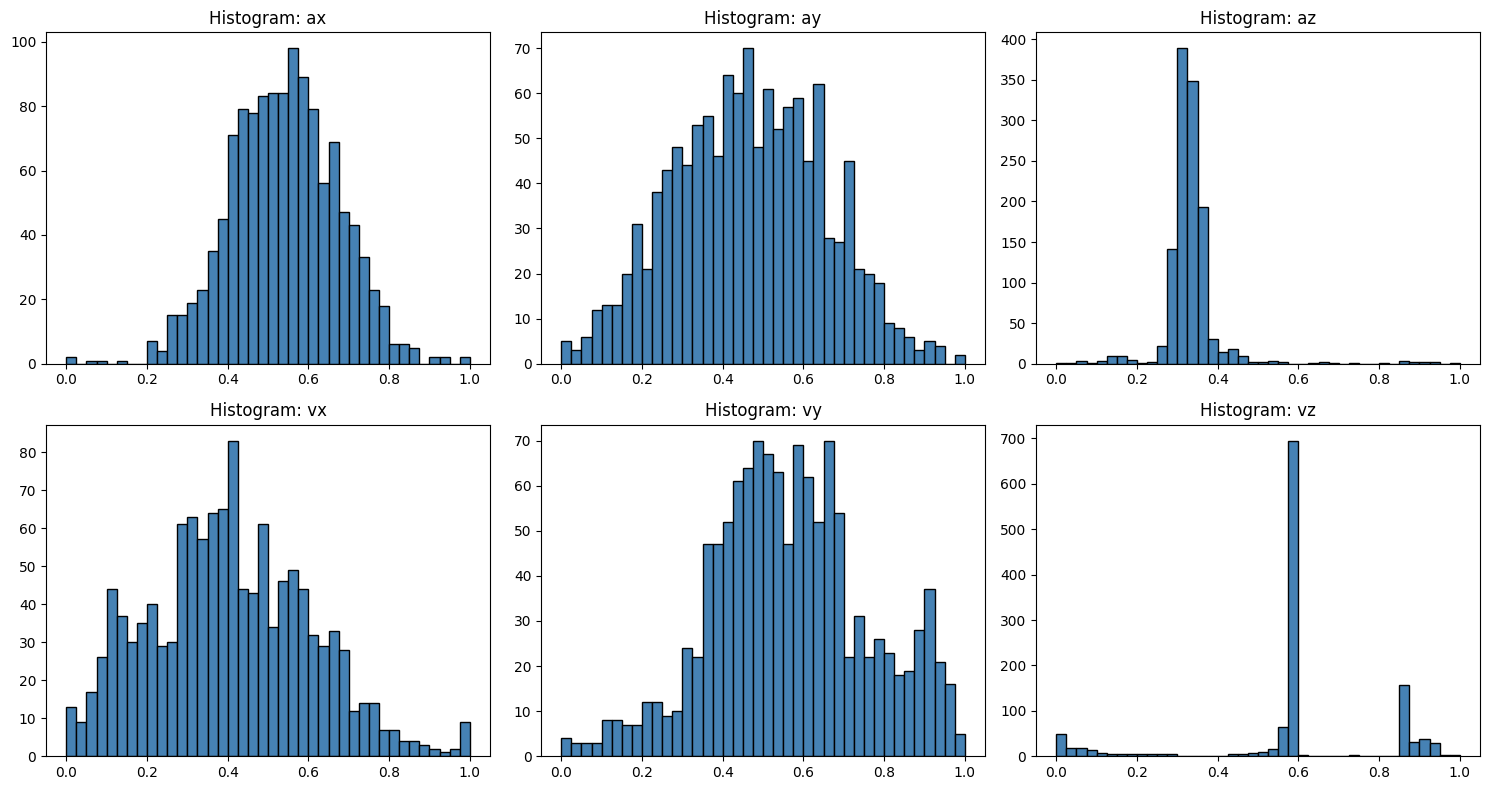

In [4]:
# Histograms
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), FEATURE_COLS + TARGET_COLS):
    ax.hist(df[col], bins=40, color='steelblue', edgecolor='black')
    ax.set_title(f'Histogram: {col}')
plt.tight_layout()
plt.show()

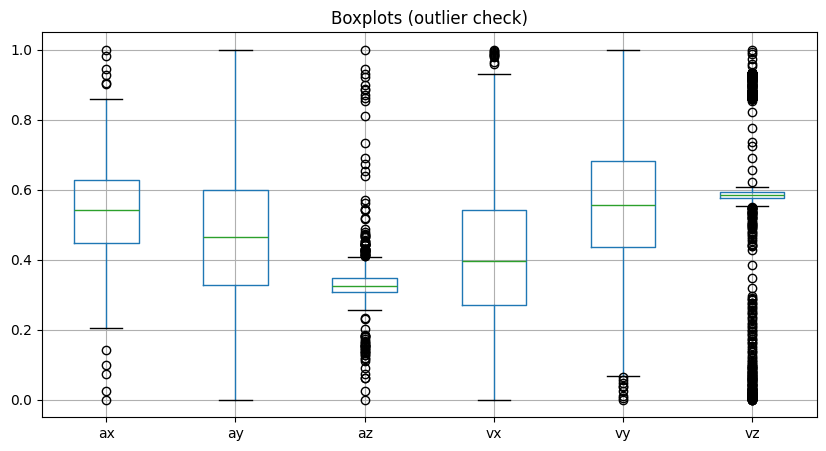

In [5]:
# Boxplots to inspect outliers
fig, ax = plt.subplots(figsize=(10, 5))
df[FEATURE_COLS + TARGET_COLS].boxplot(ax=ax)
ax.set_title('Boxplots (outlier check)')
plt.show()

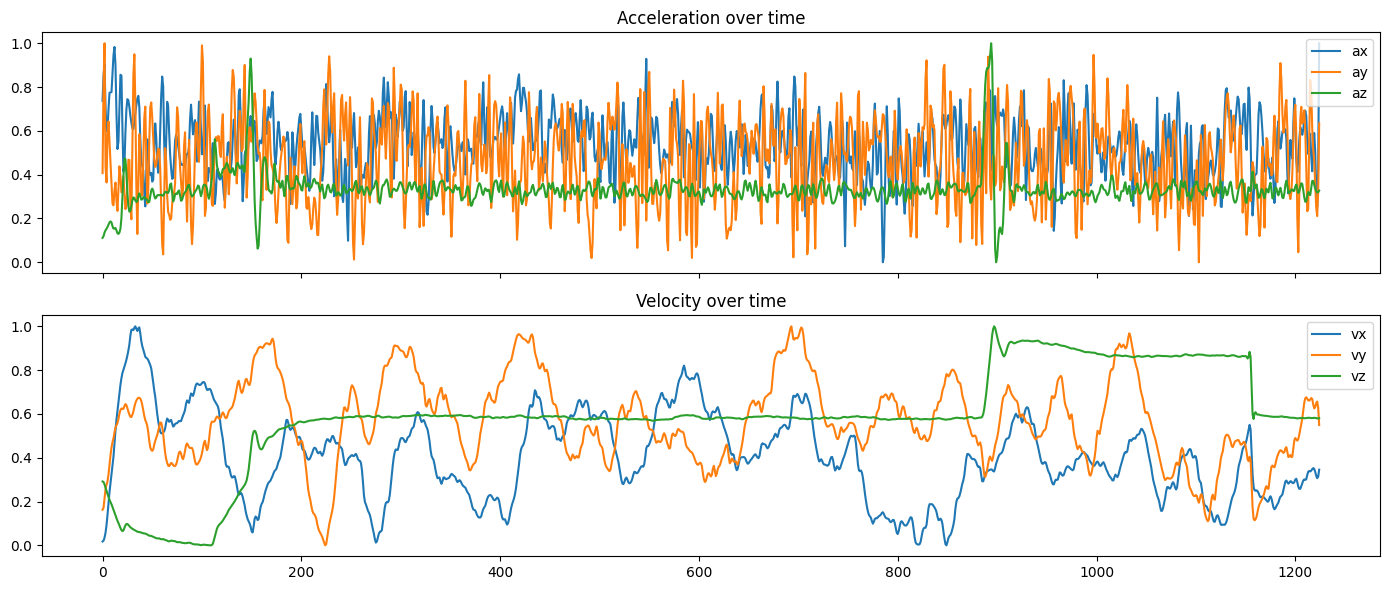

In [6]:
# Time-series plot to see the raw signal shape over the flight
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
df[FEATURE_COLS].plot(ax=axes[0], title='Acceleration over time')
df[TARGET_COLS].plot(ax=axes[1], title='Velocity over time')
plt.tight_layout()
plt.show()

## 3. Clean nulls

In [7]:
before = len(df)
df = df.dropna().reset_index(drop=True)
print(f'Removed {before - len(df)} rows containing null values. Remaining: {len(df)}')

Removed 0 rows containing null values. Remaining: 1225


## 4. Chronological train / validation / test split (70 / 10 / 20)

In [8]:
n = len(df)
train_end = int(n * 0.70)
val_end = train_end + int(n * 0.10)

train_df = df.iloc[:train_end].reset_index(drop=True)
val_df = df.iloc[train_end:val_end].reset_index(drop=True)
test_df = df.iloc[val_end:].reset_index(drop=True)

print('Train:', len(train_df), 'Val:', len(val_df), 'Test:', len(test_df))

Train: 857 Val: 122 Test: 246


## 5. Sliding-window dataset

`WINDOW_SIZE` past accelerometer readings `(ax, ay, az)` are used to predict the velocity `(vx, vy, vz)` at the timestep immediately *after* the window (i.e. the next value).

In [9]:
WINDOW_SIZE = 30

def create_windows(accel, velocity, window_size):
    """
    Create sequences for joint next-step prediction.

    Input:
        accel:
            Array with shape (N, 3), containing ax, ay, az.

        velocity:
            Array with shape (N, 3), containing vx, vy, vz.

        window_size:
            Number of historical acceleration samples.

    Output:
        X:
            Shape (num_windows, window_size, 3).

        y:
            Shape (num_windows, 6).

            Output order:
            [ax_next, ay_next, az_next,
             vx_next, vy_next, vz_next]
    """

    X = []
    y = []

    number_of_samples = len(accel)

    for end_index in range(window_size - 1, number_of_samples - 1):

        start_index = end_index - window_size + 1

        # Historical acceleration from t-29 through t
        acceleration_window = accel[
            start_index:end_index + 1
        ]

        # Acceleration at t+1
        next_acceleration = accel[end_index + 1]

        # Velocity at t+1
        next_velocity = velocity[end_index + 1]

        # Six-value target
        next_target = np.concatenate(
            (
                next_acceleration,
                next_velocity
            )
        )

        X.append(acceleration_window)
        y.append(next_target)

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32)
    )
X_train, y_train = create_windows(train_df[FEATURE_COLS].values, train_df[TARGET_COLS].values, WINDOW_SIZE)
X_val, y_val = create_windows(val_df[FEATURE_COLS].values, val_df[TARGET_COLS].values, WINDOW_SIZE)
X_test, y_test = create_windows(test_df[FEATURE_COLS].values, test_df[TARGET_COLS].values, WINDOW_SIZE)

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val:', X_val.shape, 'y_val:', y_val.shape)
print('X_test:', X_test.shape, 'y_test:', y_test.shape)

X_train: (827, 30, 3) y_train: (827, 6)
X_val: (92, 30, 3) y_val: (92, 6)
X_test: (216, 30, 3) y_test: (216, 6)


In [10]:
class IMUWindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32

train_loader = DataLoader(IMUWindowDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(IMUWindowDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(IMUWindowDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

## 6. Model: 1-layer GRU + ReLU + Linear

In [11]:
import torch
import torch.nn as nn


class AccelToAccVelGRU(nn.Module):
    """
    Compact GRU for joint next-step prediction.

    Input:
        Historical acceleration window.

        Shape:
            (batch_size, window_size, 3)

        Input order:
            [ax, ay, az]

    Output:
        Next-step acceleration and velocity.

        Shape:
            (batch_size, 6)

        Output order:
            [ax_next, ay_next, az_next,
             vx_next, vy_next, vz_next]
    """

    def __init__(
        self,
        input_size=3,
        hidden_size=32,
        num_layers=1,
        output_size=6
    ):
        super().__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.output_size = output_size

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0
        )

        self.relu = nn.ReLU()

        # One joint output layer:
        # 3 acceleration values + 3 velocity values
        self.fc = nn.Linear(
            in_features=hidden_size,
            out_features=output_size
        )

    def forward(self, x):
        """
        x shape:
            (batch_size, window_size, 3)
        """

        _, hidden = self.gru(x)

        # Last GRU layer's final hidden state
        final_hidden = hidden[-1]

        final_hidden = self.relu(final_hidden)

        predictions = self.fc(final_hidden)

        return predictions

In [13]:

INPUT_SIZE = 3
HIDDEN_SIZE = 32
NUM_LAYERS = 1
OUTPUT_SIZE = 6
WINDOW_SIZE = 30
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AccelToAccVelGRU(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    output_size=OUTPUT_SIZE
).to(device)


In [14]:
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print("Total parameters:", total_parameters)#Total parameters: 3750 # 3750 × 4 (float32) = 15,000 bytes

Total parameters: 3750


## 7. Training loop

In [15]:
EPOCHS = 100
LEARNING_RATE = 1e-3

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

ACCEL_LOSS_WEIGHT = 0.5
VELOCITY_LOSS_WEIGHT = 0.5

train_losses = []
validation_losses = []

best_validation_loss = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_training_loss = 0.0

    for xb, yb in train_loader:

        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        predictions = model(xb)

        predicted_acceleration = predictions[:, 0:3]
        predicted_velocity = predictions[:, 3:6]

        target_acceleration = yb[:, 0:3]
        target_velocity = yb[:, 3:6]
        acceleration_loss = criterion(predicted_acceleration, target_acceleration )
        velocity_loss = criterion( predicted_velocity,  target_velocity)
        loss = (
            ACCEL_LOSS_WEIGHT * acceleration_loss
            +
            VELOCITY_LOSS_WEIGHT * velocity_loss
        )

        loss.backward()
        optimizer.step()

        running_training_loss += (
            loss.item() * xb.size(0)
        )

    training_loss = (
        running_training_loss
        / len(train_loader.dataset)
    )

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    running_validation_loss = 0.0

    with torch.no_grad():

        for xb, yb in val_loader:

            xb = xb.to(device)
            yb = yb.to(device)

            predictions = model(xb)

            predicted_acceleration = predictions[:, 0:3]
            predicted_velocity = predictions[:, 3:6]

            target_acceleration = yb[:, 0:3]
            target_velocity = yb[:, 3:6]

            acceleration_loss = criterion( predicted_acceleration,target_acceleration)
            velocity_loss = criterion(  predicted_velocity,target_velocity)

            loss = (
                ACCEL_LOSS_WEIGHT * acceleration_loss
                +
                VELOCITY_LOSS_WEIGHT * velocity_loss
            )

            running_validation_loss += (
                loss.item() * xb.size(0)
            )

    validation_loss = (
        running_validation_loss
        / len(val_loader.dataset)
    )

    train_losses.append(training_loss)
    validation_losses.append(validation_loss)

    if validation_loss < best_validation_loss:

        best_validation_loss = validation_loss

        best_state = {
            name: value.detach().cpu().clone()
            for name, value
            in model.state_dict().items()
        }

    if epoch == 1 or epoch % 10 == 0:

        print(
            "Epoch {:3d}/{}, "
            "train_loss={:.6f}, "
            "val_loss={:.6f}".format(
                epoch,
                EPOCHS,
                training_loss,
                validation_loss
            )
        )

model.load_state_dict(best_state)

print(
    "\nBest validation loss: {:.6f}".format(
        best_validation_loss
    )
)

Epoch   1/100, train_loss=0.172196, val_loss=0.144853
Epoch  10/100, train_loss=0.026543, val_loss=0.045724
Epoch  20/100, train_loss=0.024353, val_loss=0.043826
Epoch  30/100, train_loss=0.022215, val_loss=0.043624
Epoch  40/100, train_loss=0.018764, val_loss=0.044432
Epoch  50/100, train_loss=0.015635, val_loss=0.040966
Epoch  60/100, train_loss=0.014110, val_loss=0.040476
Epoch  70/100, train_loss=0.013743, val_loss=0.040883
Epoch  80/100, train_loss=0.012954, val_loss=0.038408
Epoch  90/100, train_loss=0.012429, val_loss=0.037731
Epoch 100/100, train_loss=0.011923, val_loss=0.038979

Best validation loss: 0.037481


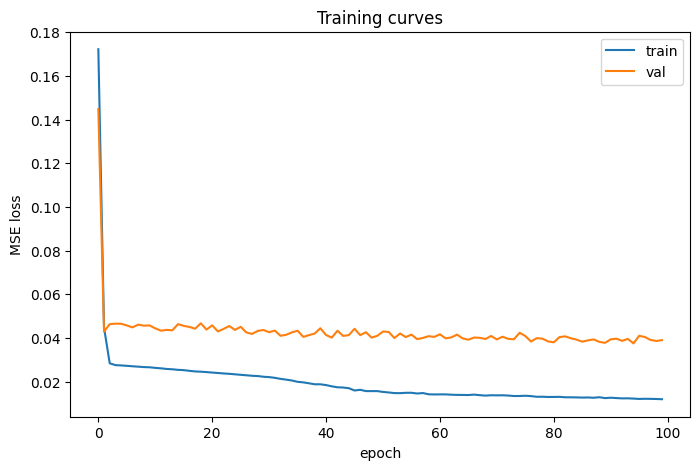

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='train')
plt.plot(validation_losses, label='val')
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.title('Training curves')
plt.legend()
plt.show()

## 8. Test set evaluation

In [22]:
model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():

    for xb, yb in test_loader:

        xb = xb.to(device)

        predictions = model(xb)

        all_predictions.append(
            predictions.cpu().numpy()
        )

        all_targets.append(
            yb.numpy()
        )

all_predictions = np.concatenate(
    all_predictions,
    axis=0
)

all_targets = np.concatenate(
    all_targets,
    axis=0
)

# Separate acceleration and velocity
predicted_acceleration = all_predictions[:, 0:3]
predicted_velocity = all_predictions[:, 3:6]

target_acceleration = all_targets[:, 0:3]
target_velocity = all_targets[:, 3:6]

acceleration_mse = np.mean(
    (
        predicted_acceleration
        - target_acceleration
    ) ** 2
)

velocity_mse = np.mean(
    (
        predicted_velocity
        - target_velocity
    ) ** 2
)

acceleration_mae_per_axis = np.mean(
    np.abs(
        predicted_acceleration
        - target_acceleration
    ),
    axis=0
)

velocity_mae_per_axis = np.mean(
    np.abs(
        predicted_velocity
        - target_velocity
    ),
    axis=0
)

print(
    "Acceleration MSE: {:.6f}".format(
        acceleration_mse
    )
)

print(
    "Acceleration MAE per axis "
    "(ax, ay, az):",
    acceleration_mae_per_axis
)

print(
    "Velocity MSE: {:.6f}".format(
        velocity_mse
    )
)

print(
    "Velocity MAE per axis "
    "(vx, vy, vz):",
    velocity_mae_per_axis
)

Acceleration MSE: 0.004556
Acceleration MAE per axis (ax, ay, az): [0.07431645 0.04959447 0.02136596]
Velocity MSE: 0.046510
Velocity MAE per axis (vx, vy, vz): [0.11037065 0.13110864 0.25810242]


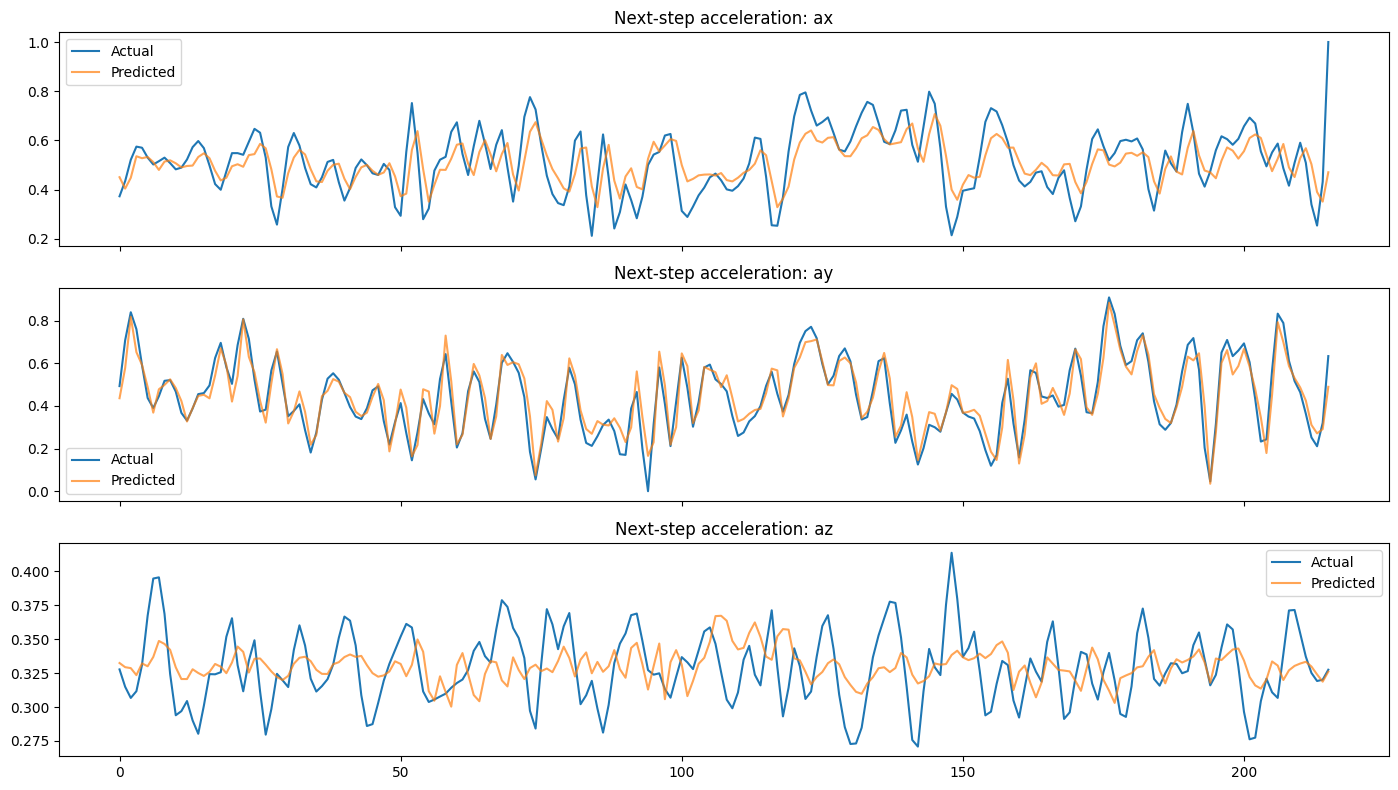

In [23]:
# Visual check: predicted vs actual acc on the test set
fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 8),
    sharex=True
)

labels = ["ax", "ay", "az"]

for axis_index, plot_axis in enumerate(axes):

    plot_axis.plot(
        target_acceleration[:, axis_index],
        label="Actual"
    )

    plot_axis.plot(
        predicted_acceleration[:, axis_index],
        label="Predicted",
        alpha=0.7
    )

    plot_axis.set_title(
        "Next-step acceleration: {}".format(
            labels[axis_index]
        )
    )

    plot_axis.legend()

plt.tight_layout()
plt.show()

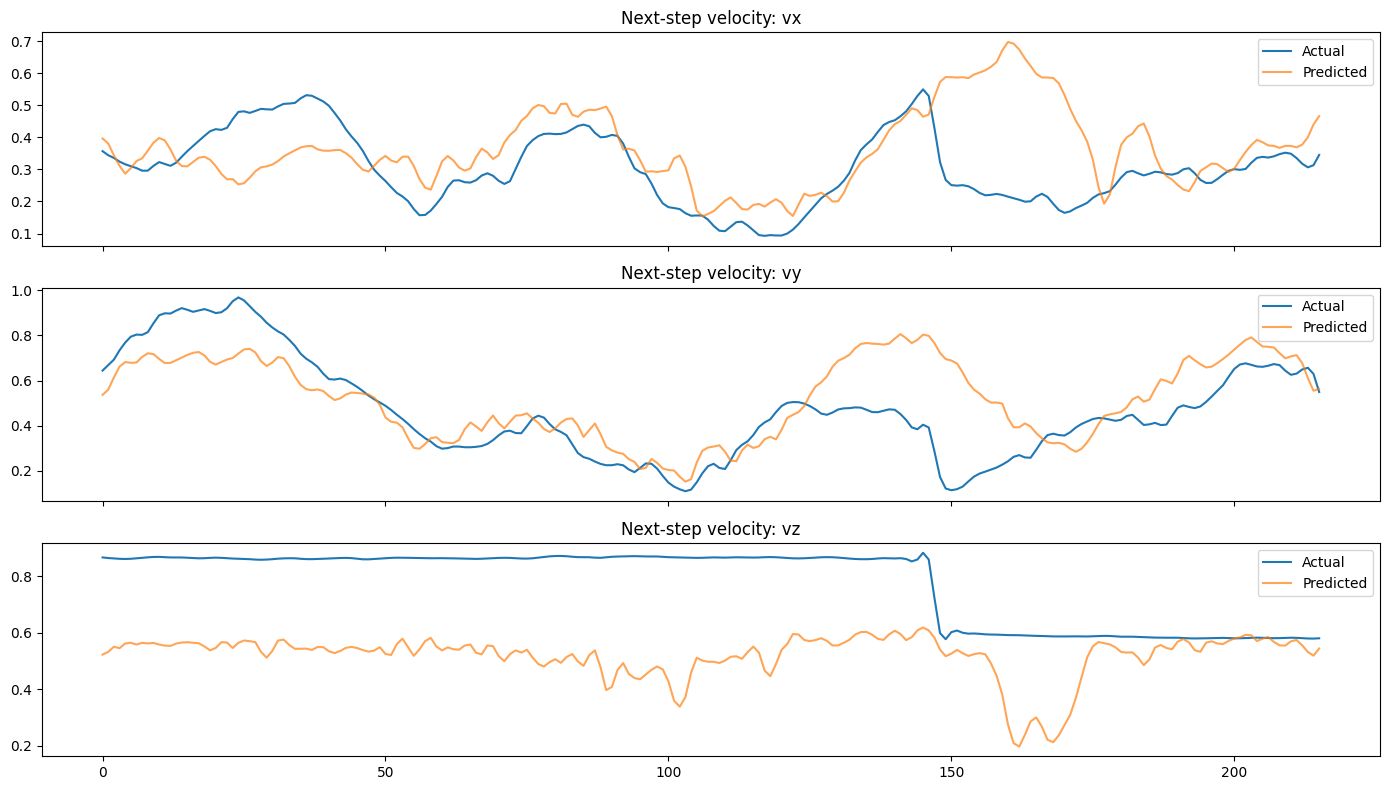

In [24]:
# Visual check: predicted vs actual velocity on the test set
fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 8),
    sharex=True
)

labels = ["vx", "vy", "vz"]

for axis_index, plot_axis in enumerate(axes):

    plot_axis.plot(
        target_velocity[:, axis_index],
        label="Actual"
    )

    plot_axis.plot(
        predicted_velocity[:, axis_index],
        label="Predicted",
        alpha=0.7
    )

    plot_axis.set_title(
        "Next-step velocity: {}".format(
            labels[axis_index]
        )
    )

    plot_axis.legend()

plt.tight_layout()
plt.show()

## 9. Save weights for later use in the Wokwi/Pico environment

Saves the state dict plus the architecture config needed to reconstruct the model (window size, hidden size, num layers) so the export step (converting to a MicroPython-loadable format) has everything it needs.

In [25]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "input_size": INPUT_SIZE,
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
    "output_size": OUTPUT_SIZE,
    "window_size": WINDOW_SIZE
}

torch.save(
    checkpoint,
    "gru_imu_model.pth"
)

print(
    "Compact acceleration-velocity GRU "
    "checkpoint saved."
)

Compact acceleration-velocity GRU checkpoint saved.
